Station B

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
customers = pd.read_csv("data/csv/customers.csv")
products = pd.read_csv("data/csv/products.csv")
orders = pd.read_csv("data/csv/orders.csv")
support_tickets = pd.read_csv("data/csv/support_tickets.csv")
daily_ops = pd.read_csv("data/csv/daily_ops.csv")
image_labels = pd.read_csv("data/csv/image_labels.csv")

Basic Inspection

In [26]:
print("Customers:", customers.shape)
print("Products:", products.shape)
print("Orders:", orders.shape)
print("Support Tickets:", support_tickets.shape)
print("Daily Ops:", daily_ops.shape)
print("Image Labels:", image_labels.shape)

Customers: (862, 12)
Products: (15, 6)
Orders: (3388, 10)
Support Tickets: (520, 8)
Daily Ops: (608, 6)
Image Labels: (240, 2)


Finding the missing data

In [27]:
print("Customers Missing Values")
print(customers.isnull().sum())

print("\n Orders Missing Values")
print(orders.isnull().sum())

print("\n Support Tickets Missing Values")
print(support_tickets.isnull().sum())

print("\n Products Missing Values")
print(products.isnull().sum())

Customers Missing Values
customer_id          0
first_name           0
last_name            0
email                0
phone               17
city                 0
state                0
signup_date          0
plan                 0
age                 27
last_active_date     0
churned              0
dtype: int64

 Orders Missing Values
order_id        0
customer_id     0
product_id      0
order_date      0
channel         0
quantity        0
unit_price      0
discount_pct    0
returned        0
status          0
dtype: int64

 Support Tickets Missing Values
ticket_id       0
customer_id     0
order_id        0
created_at      0
ticket_type    31
priority        0
raw_message     0
resolved        0
dtype: int64

 Products Missing Values
product_id      0
sku             0
product_name    0
category        0
unit_cost       0
list_price      0
dtype: int64


Finding Duplicates

In [28]:
duplicate_customers = customers.duplicated().sum()
duplicate_emails = customers["email"].duplicated().sum()
print("Duplicate customer rows:", duplicate_customers)
print("Duplicate customer emails:", duplicate_emails)

Duplicate customer rows: 0
Duplicate customer emails: 12


Finding Broken Emails

In [29]:
# code for finding out broken emails
import re

email_pattern = r"^[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}$"

customers["email_valid"] = customers["email"].fillna("").str.match(
    email_pattern
)

customers[~customers["email_valid"]][["customer_id", "email"]]
print("Invalid emails:", (~customers["email_valid"]).sum())
customers["email_valid"].value_counts()

Invalid emails: 20


email_valid
True     842
False     20
Name: count, dtype: int64

As the Customer table has 2 missing values i.e, Phone, Age we are fixing them now

Inspecting phone data

In [32]:
missing_phone = customers[customers["phone"].isna()]
print("Missing phone values:", len(missing_phone))

Missing phone values: 17


Fixing phone data

In [33]:
customers["phone"] = customers["phone"].fillna("Unknown")
print("Missing phone values after fixing:", customers["phone"].isna().sum())

Missing phone values after fixing: 0


Inspecting age data

In [35]:
missing_age = customers[customers["age"].isna()]
print("Missing age values:", len(missing_age))

Missing age values: 27


Fixing age data

In [39]:
print(customers["age"].describe())
age_median = customers["age"].median()
print("Median age:", age_median)
customers["age"] = customers["age"].fillna(age_median)
print("Missing age values after fixing:", customers["age"].isna().sum())

count    862.000000
mean      32.558005
std        8.052427
min       18.000000
25%       27.000000
50%       33.000000
75%       38.000000
max       58.000000
Name: age, dtype: float64
Median age: 33.0
Missing age values after fixing: 0


Orders table has no missing values, Support Tickets table has missing values in ticket_type so we will inspect it and fix it

In [44]:
missing_ticket_type = support_tickets[support_tickets["ticket_type"].isna()]
print("Missing ticket types:", len(missing_ticket_type))
support_tickets["ticket_type"].value_counts(dropna=False)

Missing ticket types: 31


ticket_type
delivery          142
return            117
product_defect     98
account            76
billing            56
NaN                31
Name: count, dtype: int64

Fix:- The 31 missing ticket_type values were replaced with "Unknown" instead of guessing the ticket category.

In [45]:
support_tickets["ticket_type"] = support_tickets["ticket_type"].fillna("Unknown")
print("Missing ticket types after fixing:", support_tickets["ticket_type"].isna().sum())

Missing ticket types after fixing: 0


Finding Duplicate Emails

In [48]:
duplicate_emails = customers[ customers["email"].duplicated(keep=False) ]
print("Duplicate customer emails:", len(duplicate_emails))

Duplicate customer emails: 24


Fixing Duplicate Emails

In [51]:
duplicate_emails.sort_values("email")
customers = customers.drop_duplicates(subset="email",keep="first")
duplicate_emails_after = customers["email"].duplicated().sum()
print("Duplicate emails after fixing:", duplicate_emails_after)

Duplicate emails after fixing: 0


Finding Orphan Orders

In [52]:
orphan_orders = orders[
    ~orders["customer_id"].isin(customers["customer_id"])
]

print("Orphan orders:", len(orphan_orders))
orphan_orders

Orphan orders: 25


,order_id,customer_id,product_id,order_date,channel,quantity,unit_price,discount_pct,returned,status
3363,90001,39999,1011,2025-01-30,ios,1,24.0,5.0,0,delivered
3364,90002,39999,1015,2025-07-16,android,1,49.0,0.0,0,delivered
3365,90003,39999,1002,2025-12-14,web,1,149.0,0.0,0,delivered
3366,90004,39999,1006,2025-08-29,web,1,199.0,0.0,0,delivered
3367,90005,39999,1013,2026-03-12,web,1,34.0,0.0,1,returned
3368,90006,39999,1011,2026-02-14,ios,3,24.0,0.0,0,delivered
3369,90007,39999,1010,2025-10-09,store,1,29.0,0.0,0,delivered
3370,90008,39999,1004,2026-05-24,web,1,79.0,0.0,0,delivered
3371,90009,39999,1011,2026-03-18,android,1,24.0,10.0,0,delivered
3372,90010,39999,1008,2025-04-02,store,1,39.0,0.0,0,delivered


Fix:- Removing them because we cannot assign these orders to real customers, so for customer-level analysis we should remove them rather than invent a mapping

In [53]:
orders = orders[
    orders["customer_id"].isin(customers["customer_id"])
].copy()
orphan_orders_after = orders[
    ~orders["customer_id"].isin(customers["customer_id"])
]

print("Orphan orders after fixing:", len(orphan_orders_after))

Orphan orders after fixing: 0


Inspecting Impossible Prices

In [54]:
print(orders["unit_price"].describe())

count    3363.000000
mean       81.206661
std        70.341830
min        15.000000
25%        34.000000
50%        69.000000
75%       119.000000
max      1490.000000
Name: unit_price, dtype: float64


From my thinking impossible prices in the sense i am expecting negative values here

In [55]:
impossible_prices = orders[ orders["unit_price"] <= 0 ]
print("Impossible prices:", len(impossible_prices))
impossible_prices

Impossible prices: 0


,order_id,customer_id,product_id,order_date,channel,quantity,unit_price,discount_pct,returned,status


Now there are no negative values so i will search top 20 prices

In [57]:
orders["unit_price"].sort_values(ascending=False).head(20)

3172    1490.0
2117    1490.0
1906     890.0
429      890.0
2539     890.0
2750     890.0
1695     890.0
218      490.0
7        490.0
1484     490.0
1062     490.0
851      240.0
1273     240.0
2034     199.0
2051     199.0
1374     199.0
1505     199.0
1046     199.0
3310     199.0
167      199.0
Name: unit_price, dtype: float64

The order prices were compared with the corresponding product list prices. 16 orders were found with prices that did not match the product prices.

In [58]:
price_check = orders.merge(
    products[["product_id", "list_price"]],
    on="product_id"
)

impossible_prices = price_check[
    price_check["unit_price"] != price_check["list_price"]
]

print("Impossible prices:", len(impossible_prices))
impossible_prices[["order_id", "product_id", "unit_price", "list_price"]]

Impossible prices: 16


,order_id,product_id,unit_price,list_price
7,50007,1015,490.0,49.0
218,50218,1015,490.0,49.0
429,50429,1001,890.0,89.0
640,50640,1012,150.0,15.0
851,50851,1011,240.0,24.0
1062,51062,1015,490.0,49.0
1273,51273,1011,240.0,24.0
1484,51484,1015,490.0,49.0
1695,51695,1014,890.0,89.0
1906,51906,1001,890.0,89.0


Fix:- The 16 mismatched order prices were replaced with the corresponding product list prices. No order records were dropped.

In [61]:
orders = orders.merge(
    products[["product_id", "list_price"]],
    on="product_id"
)

orders["unit_price"] = orders["list_price"]

orders = orders.drop(columns=["list_price"])
price_check = orders.merge(
    products[["product_id", "list_price"]],
    on="product_id"
)

print(
    "Price mismatches after fixing:",
    (price_check["unit_price"] != price_check["list_price"]).sum()
)

Price mismatches after fixing: 0


EDA Part

1. City vs Churn

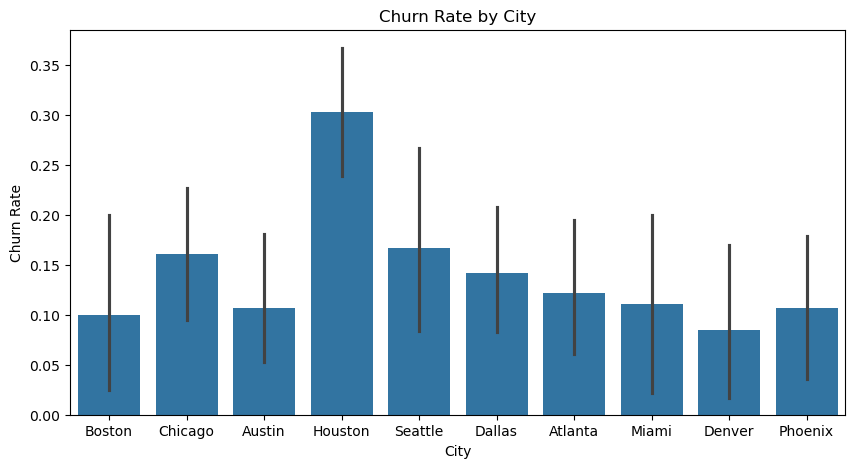

In [70]:
plt.figure(figsize=(10, 5))
sns.barplot(data=customers, x="city", y="churned")
plt.title("Churn Rate by City")
plt.xlabel("City")
plt.ylabel("Churn Rate")
plt.show()

2. Category vs Return Rate

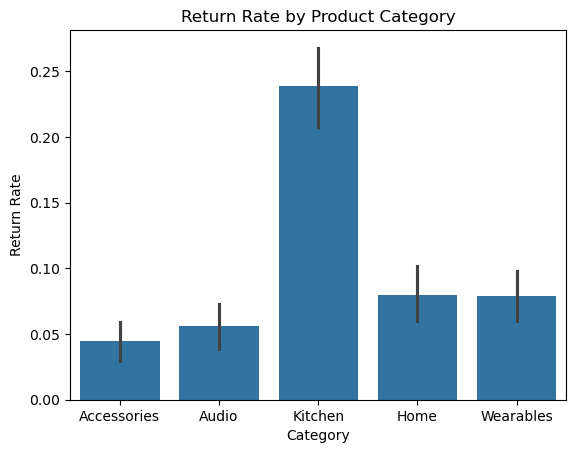

In [71]:
orders_products = orders.merge(products, on="product_id")
sns.barplot(data=orders_products, x="category", y="returned")
plt.title("Return Rate by Product Category")
plt.xlabel("Category")
plt.ylabel("Return Rate")
plt.show()

3. Price Distribution and Outliers

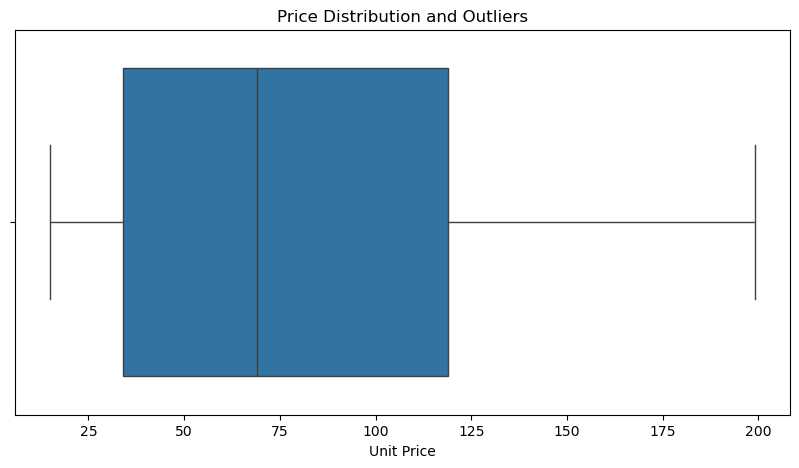

In [73]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=orders["unit_price"])
plt.title("Price Distribution and Outliers")
plt.xlabel("Unit Price")
plt.show()

Station C

1. Measures of center & spread

Order Values

In [76]:
orders["order_value"] = orders["quantity"] * orders["unit_price"]
print("Order Value Statistics:")
print(orders["order_value"].describe())

Order Value Statistics:
count    3363.000000
mean       88.230746
std        67.841938
min        15.000000
25%        39.000000
50%        72.000000
75%       119.000000
max       597.000000
Name: order_value, dtype: float64


Order values have a mean of 88.23 and a median of 72. The standard deviation is 67.84, showing considerable variation in order values.

Customer Order Count

In [77]:
customer_order_count = orders.groupby("customer_id").size()
print("Customer Order Count Statistics:")
print(customer_order_count.describe())

Customer Order Count Statistics:
count    850.000000
mean       3.956471
std        2.158990
min        1.000000
25%        2.000000
50%        4.000000
75%        6.000000
max       10.000000
dtype: float64


Customers placed an average of 3.96 orders, with a median of 4 orders. The standard deviation of 2.16 shows some variation in order frequency, with customers placing between 1 and 10 orders.

Association View

In [78]:
city_churn = customers.groupby("city")["churned"].mean()
print(city_churn)

city
Atlanta    0.121951
Austin     0.106383
Boston     0.100000
Chicago    0.160377
Dallas     0.141667
Denver     0.084746
Houston    0.303191
Miami      0.111111
Phoenix    0.107143
Seattle    0.166667
Name: churned, dtype: float64


Association: Churn rates differ across cities, with Houston having the highest observed rate and Denver the lowest. This is an association between city and churn; it does not by itself show that city causes churn.

Hypothesis Test - 1

churn rate in one city versus everyone else (here we are using houston because it has highest churn rate)

In [79]:
houston = customers[customers["city"] == "Houston"]
other_cities = customers[customers["city"] != "Houston"]
print("Houston customers:", len(houston))
print("Other city customers:", len(other_cities))

Houston customers: 188
Other city customers: 662


In [83]:
from statsmodels.stats.proportion import proportions_ztest
houston_churned = houston["churned"].sum()
other_churned = other_cities["churned"].sum()
count = [houston_churned, other_churned]
nobs = [len(houston), len(other_cities)]
z_stat, p_value = proportions_ztest(count, nobs)
print("Houston churned:", houston_churned)
print("Other cities churned:", other_churned)
print("Z-statistic:", z_stat)
print("P-value:", p_value)

Houston churned: 57
Other cities churned: 84
Z-statistic: 5.735153950683825
P-value: 9.74238124657715e-09


Hypothesis Test 1: Houston Churn vs Other Cities
1. H0: The churn rate in Houston is equal to the churn rate in other cities.
2. Test: Two-proportion z-test.
3. P-value: 9.74238124657715e-09
4. Interpretation: The p-value is below 0.05, so there is strong statistical evidence that the churn rate in Houston is different from the churn rate in other cities.
5. Manager takeaway: Houston shows a statistically significant difference in churn compared with the other cities, so it is worth investigating further.

Hypothesis Test 2

Return rate for one category versus the other categories.

In [84]:
kitchen = orders_products[orders_products["category"] == "Kitchen"]
other_categories = orders_products[orders_products["category"] != "Kitchen"]
print("Kitchen orders:", len(kitchen))
print("Other category orders:", len(other_categories))

Kitchen orders: 713
Other category orders: 2650


In [85]:
from statsmodels.stats.proportion import proportions_ztest
kitchen_returned = kitchen["returned"].sum()
other_returned = other_categories["returned"].sum()
count = [kitchen_returned, other_returned]
nobs = [len(kitchen), len(other_categories)]
z_stat, p_value = proportions_ztest(count, nobs)
print("Kitchen returned:", kitchen_returned)
print("Other categories returned:", other_returned)
print("Z-statistic:", z_stat)
print("P-value:", p_value)

Kitchen returned: 170
Other categories returned: 172
Z-statistic: 13.608211457580818
P-value: 3.5789540792438126e-42


Hypothesis Test 2: Kitchen Return Rate vs Other Categories
1. H0: The return rate for Kitchen products is equal to the return rate of other categories.
2. Test: Two-proportion z-test.
3. P-value: 3.58e-42.
4. Interpretation: The p-value is below 0.05, so there is strong statistical evidence that the Kitchen return rate differs from the return rate of other categories.
5. Manager takeaway: Kitchen products show a statistically significant difference in returns compared with other categories, so the category should be investigated further.

Station D

Primary target: customers.churned, now we have to set the target i.e, churned

In [87]:
print(customers["churned"].value_counts())
print(customers["churned"].value_counts(normalize=True))

churned
0    709
1    141
Name: count, dtype: int64
churned
0    0.834118
1    0.165882
Name: proportion, dtype: float64


Creating Cutoff Date Feature

In [90]:
orders["order_date"] = pd.to_datetime(orders["order_date"])

cutoff_date = pd.Timestamp("2026-06-01")

orders_before_cutoff = orders[
    orders["order_date"] < cutoff_date
].copy()

print("Orders before cutoff:", len(orders_before_cutoff))
customer_features = orders_before_cutoff.groupby("customer_id").agg(
    order_count=("order_id", "count"),
    total_spend=("order_value", "sum")
).reset_index()

customer_features.head()

Orders before cutoff: 2649


,customer_id,order_count,total_spend
0,10001,3,108.0
1,10002,6,510.0
2,10003,2,93.0
3,10004,6,1156.0
4,10005,4,874.0


Add Return Rate

In [92]:
return_features = orders_before_cutoff.groupby("customer_id").agg(
    return_rate=("returned", "mean")
).reset_index()

customer_features = customer_features.merge(
    return_features,
    on="customer_id",
    how="left"
)

customer_features.head()

,customer_id,order_count,total_spend,return_rate
0,10001,3,108.0,0.000000
1,10002,6,510.0,0.500000
2,10003,2,93.0,0.000000
3,10004,6,1156.0,0.166667
4,10005,4,874.0,0.500000


Ticket Count

In [93]:
support_tickets["created_at"] = pd.to_datetime(
    support_tickets["created_at"]
)
tickets_before_cutoff = support_tickets[
    support_tickets["created_at"] < cutoff_date
].copy()
ticket_features = tickets_before_cutoff.groupby("customer_id").size().reset_index(
    name="ticket_count"
)

customer_features = customer_features.merge(
    ticket_features,
    on="customer_id",
    how="left"
)

customer_features["ticket_count"] = customer_features["ticket_count"].fillna(0)

customer_features.head()

,customer_id,order_count,total_spend,return_rate,ticket_count
0,10001,3,108.0,0.000000,0.0
1,10002,6,510.0,0.500000,0.0
2,10003,2,93.0,0.000000,2.0
3,10004,6,1156.0,0.166667,0.0
4,10005,4,874.0,0.500000,0.0


Adding Customer Information

In [94]:
customer_features = customer_features.merge(
    customers[
        ["customer_id", "plan", "city", "age", "churned"]
    ],
    on="customer_id",
    how="left"
)

customer_features.head()

,customer_id,order_count,total_spend,return_rate,ticket_count,plan,city,age,churned
0,10001,3,108.0,0.000000,0.0,free,Boston,42.0,0
1,10002,6,510.0,0.500000,0.0,plus,Chicago,36.0,0
2,10003,2,93.0,0.000000,2.0,pro,Austin,41.0,0
3,10004,6,1156.0,0.166667,0.0,free,Houston,18.0,0
4,10005,4,874.0,0.500000,0.0,free,Chicago,38.0,0


Calculating Recency

In [95]:
last_order = orders_before_cutoff.groupby("customer_id")["order_date"].max().reset_index()

last_order["recency_days"] = (
    cutoff_date - last_order["order_date"]
).dt.days

customer_features = customer_features.merge(
    last_order[["customer_id", "recency_days"]],
    on="customer_id",
    how="left"
)

customer_features.head()

,customer_id,order_count,total_spend,return_rate,ticket_count,plan,city,age,churned,recency_days
0,10001,3,108.0,0.000000,0.0,free,Boston,42.0,0,95
1,10002,6,510.0,0.500000,0.0,plus,Chicago,36.0,0,162
2,10003,2,93.0,0.000000,2.0,pro,Austin,41.0,0,119
3,10004,6,1156.0,0.166667,0.0,free,Houston,18.0,0,8
4,10005,4,874.0,0.500000,0.0,free,Chicago,38.0,0,7


Train/Test Split

In [96]:
customer_features = customer_features.merge(
    customers[["customer_id", "signup_date"]],
    on="customer_id",
    how="left"
)

customer_features["signup_date"] = pd.to_datetime(
    customer_features["signup_date"]
)

customer_features = customer_features.sort_values("signup_date")

customer_features.head()

,customer_id,order_count,total_spend,return_rate,ticket_count,plan,city,age,churned,recency_days,signup_date
358,10381,2,236.0,0.0,0.0,free,Atlanta,19.0,0,29,2025-01-01
264,10281,1,69.0,0.0,0.0,free,Austin,33.0,0,491,2025-01-01
619,10645,7,838.0,0.0,1.0,free,Denver,25.0,0,74,2025-01-01
615,10640,1,72.0,0.0,1.0,free,Chicago,56.0,0,446,2025-01-01
378,10401,1,178.0,0.0,0.0,free,Houston,23.0,1,450,2025-01-01


Split chronologically

In [97]:
split_index = int(len(customer_features) * 0.8)

train_data = customer_features.iloc[:split_index].copy()
test_data = customer_features.iloc[split_index:].copy()

print("Training customers:", len(train_data))
print("Testing customers:", len(test_data))
print("Training date range:", train_data["signup_date"].min(), "to", train_data["signup_date"].max())
print("Testing date range:", test_data["signup_date"].min(), "to", test_data["signup_date"].max())

Training customers: 655
Testing customers: 164
Training date range: 2025-01-01 00:00:00 to 2025-11-13 00:00:00
Testing date range: 2025-11-13 00:00:00 to 2026-02-04 00:00:00


Separate features and target
X = information we give the model
y = what the model needs to predict

In [104]:
features = [
    "order_count",
    "total_spend",
    "return_rate",
    "ticket_count",
    "plan",
    "city",
    "age",
    "recency_days"
]

X_train = train_data[features].copy()
y_train = train_data["churned"]

X_test = test_data[features].copy()
y_test = test_data["churned"]
#performing one-hot encoding
X_train = pd.get_dummies(
    X_train,
    columns=["plan", "city"],
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    columns=["plan", "city"],
    drop_first=True
)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (655, 17)
X_test: (164, 17)


BaseLine Model:- Here we are using single feature logistic regression and we are using recency_days as the single feature like to answer or to find out that, Can we predict churn using only how recently the customer ordered?

In [105]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, roc_auc_score

baseline = LogisticRegression()

baseline.fit(
    X_train[["recency_days"]],
    y_train
)

baseline_pred = baseline.predict(
    X_test[["recency_days"]]
)

baseline_prob = baseline.predict_proba(
    X_test[["recency_days"]]
)[:, 1]

print("Baseline Precision:", precision_score(y_test, baseline_pred))
print("Baseline Recall:", recall_score(y_test, baseline_pred))
print("Baseline ROC-AUC:", roc_auc_score(y_test, baseline_prob))

Baseline Precision: 0.0
Baseline Recall: 0.0
Baseline ROC-AUC: 0.7823270876705991


C:\Users\datta_84fscca\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Baseline: A single-feature logistic regression using recency_days achieved a ROC-AUC of 0.782. At the default classification threshold, it predicted no churned customers, resulting in 0 precision and 0 recall. This shows that recency contains useful ranking information but alone does not produce useful churn classifications at the default threshold.

Implementing Stronger Model:- Gradient Boosting

In [108]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(
    random_state=42
)

model.fit(X_train, y_train)

model_pred = model.predict(X_test)
model_prob = model.predict_proba(X_test)[:, 1]

print("Model Precision:", precision_score(y_test, model_pred))
print("Model Recall:", recall_score(y_test, model_pred))
print("Model ROC-AUC:", roc_auc_score(y_test, model_prob))

Model Precision: 0.8
Model Recall: 0.12121212121212122
Model ROC-AUC: 0.734674994216979


error analysis

In [109]:
results = test_data.copy()

results["predicted"] = model_pred

false_negatives = results[
    (results["churned"] == 1) &
    (results["predicted"] == 0)
]

false_positives = results[
    (results["churned"] == 0) &
    (results["predicted"] == 1)
]

print("False negatives:", len(false_negatives))
print("False positives:", len(false_positives))

false_negatives[
    [
        "customer_id",
        "order_count",
        "total_spend",
        "return_rate",
        "ticket_count",
        "plan",
        "city",
        "age",
        "recency_days"
    ]
].head(10)

False negatives: 29
False positives: 1


,customer_id,order_count,total_spend,return_rate,ticket_count,plan,city,age,recency_days
300,10321,5,408.0,0.400000,3.0,free,Boston,48.0,56
74,10082,3,187.0,0.000000,2.0,free,Houston,35.0,64
731,10761,3,114.0,0.000000,1.0,plus,Atlanta,22.0,151
17,10020,1,34.0,0.000000,1.0,plus,Dallas,28.0,192
528,10553,4,301.0,0.000000,1.0,plus,Houston,37.0,143
309,10332,1,398.0,0.000000,1.0,free,Miami,26.0,151
385,10408,4,366.0,0.000000,0.0,plus,Atlanta,34.0,126
557,10582,4,360.0,0.500000,0.0,free,Miami,35.0,155
449,10472,3,142.0,0.333333,1.0,free,Houston,36.0,76
466,10489,2,104.0,0.000000,1.0,free,Houston,23.0,116


Error Analysis
1. The Gradient Boosting model produced 29 false negatives and 1 false positive on the test set.
2. False negatives are customers who actually churned but were predicted as non-churned. The examples show different combinations of order count, spending, return rate, support tickets, plan, city, age, and recency, suggesting that the missed churners do not follow one simple pattern.
3. There was only 1 false positive, meaning the model rarely predicted churn for customers who did not churn.
4. Overall, the model was conservative in identifying churners: it produced relatively precise positive predictions but missed many actual churners.

Station - E

K-Means on a customer feature slice

In [110]:
cluster_features = [
    "order_count",
    "total_spend",
    "return_rate",
    "ticket_count",
    "recency_days"
]

X_cluster = customer_features[cluster_features].copy()

X_cluster.head()

,order_count,total_spend,return_rate,ticket_count,recency_days
358,2,236.0,0.0,0.0,29
264,1,69.0,0.0,0.0,491
619,7,838.0,0.0,1.0,74
615,1,72.0,0.0,1.0,446
378,1,178.0,0.0,0.0,450


Standardizing the Feautures

In [111]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_cluster_scaled = scaler.fit_transform(X_cluster)

print(X_cluster_scaled.shape)

(819, 5)


Determining the best k using elbow method, this explains where does adding another cluster stop giving a large reduction in inertia

C:\Users\datta_84fscca\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\datta_84fscca\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\datta_84fscca\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\datta_84fscca\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known

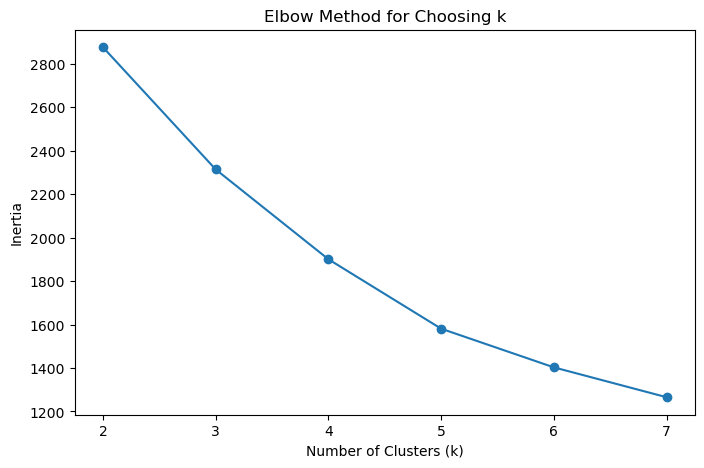

In [113]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 8), inertia, marker="o")
plt.title("Elbow Method for Choosing k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

Silhouette Score, This explains How well separated are the resulting clusters.

In [114]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster_scaled)
    score = silhouette_score(X_cluster_scaled, labels)
    silhouette_scores.append(score)

for k, score in zip(range(2, 8), silhouette_scores):
    print("k =", k, "Silhouette Score =", round(score, 3))

C:\Users\datta_84fscca\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\datta_84fscca\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\datta_84fscca\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\datta_84fscca\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known

k = 2 Silhouette Score = 0.284
k = 3 Silhouette Score = 0.317
k = 4 Silhouette Score = 0.286
k = 5 Silhouette Score = 0.289
k = 6 Silhouette Score = 0.289
k = 7 Silhouette Score = 0.307


Justification for k
Here we are choosing k=3 because the elbow plot showed that inertia decreased as the number of clusters increased, with the improvement becoming smaller at higher values of k. The elbow was not very sharp, so silhouette scores were also used to support the choice. The highest silhouette score was 0.317 at k = 3. Therefore, k = 3 was selected for the K-Means clustering.

K-Means

In [115]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_cluster_scaled)

X_cluster["cluster"] = cluster_labels

print(X_cluster.head())
print(X_cluster["cluster"].value_counts().sort_index())

C:\Users\datta_84fscca\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


     order_count  total_spend  return_rate  ticket_count  recency_days  \
358            2        236.0          0.0           0.0            29   
264            1         69.0          0.0           0.0           491   
619            7        838.0          0.0           1.0            74   
615            1         72.0          0.0           1.0           446   
378            1        178.0          0.0           0.0           450   

     cluster  
358        1  
264        1  
619        0  
615        1  
378        1  
cluster
0    341
1    423
2     55
Name: count, dtype: int64


Profiling the Clusters

In [118]:
cluster_profile = X_cluster.groupby("cluster").mean()
cluster_profile

,order_count,total_spend,return_rate,ticket_count,recency_days
cluster,,,,,
0,4.935484,458.155425,0.102023,0.894428,67.123167
1,2.075650,171.990544,0.030496,0.189125,138.413712
2,1.600000,124.490909,0.784848,0.218182,140.709091


K-Means Cluster Interpretation

The three clusters show different patterns in customer behavior.

1. Cluster 0 has the highest average order count and total spend, with the lowest recency, indicating more recent and frequent purchasing activity.
2. Cluster 1 has lower order count and spending, a low return rate, and relatively high recency.
3. Cluster 2 is the smallest cluster and has a much higher average return rate than the other clusters, despite having relatively low order count and spending.

DBSCAN on same future slice

In [119]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_cluster_scaled)

print(pd.Series(dbscan_labels).value_counts().sort_index())

-1    106
 0    446
 1    204
 2     25
 3     27
 4     11
Name: count, dtype: int64


DBSCAN
1. DBSCAN was run on the same standardized customer feature slice used for K-Means, using `eps=0.8` and `min_samples=5`.
2. The model identified 5 clusters and 106 observations as noise (`-1`). The presence of a relatively large noise group suggests that the selected density parameters do not place all customers into well-defined density regions.
3. Therefore, the DBSCAN result is treated as a density-based clustering result rather than as distinct customer personas.

Visualizing the k-means clusters

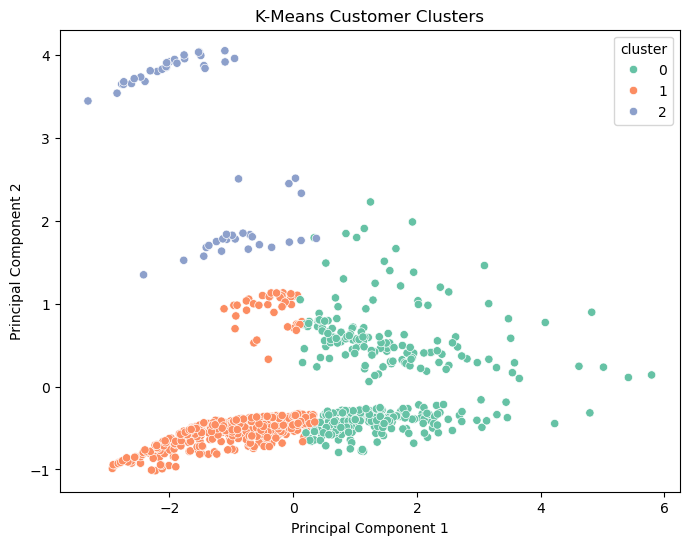

In [121]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_cluster_scaled)

cluster_plot = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": cluster_labels
})

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=cluster_plot,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set2"
)

plt.title("K-Means Customer Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

K-Means Cluster Visualization

The PCA plot shows that the three clusters have some separation.
1. Cluster 0 has higher orders and spending.
2. Cluster 1 has lower orders and spending.
3. Cluster 2 has a much higher return rate.
Some overlap can be seen between the clusters. These clusters show differences in customer behavior and are not treated as customer personas.

Section F

Prepare the data

In [122]:
daily_ops["date"] = pd.to_datetime(daily_ops["date"])
daily_ops = daily_ops.sort_values("date").reset_index(drop=True)
daily_ops.head()

,date,site_visits,orders_count,revenue_usd,support_tickets,promo_flag
0,2025-01-01,4157,114,7172.00,34,0
1,2025-01-02,4418,170,10421.59,24,0
2,2025-01-03,4169,148,10991.89,19,0
3,2025-01-04,5656,218,15004.27,25,0
4,2025-01-05,5402,228,17047.79,35,0


Plotting Daily Orders, we need to mark March 2026 promo window and June 1, 2026

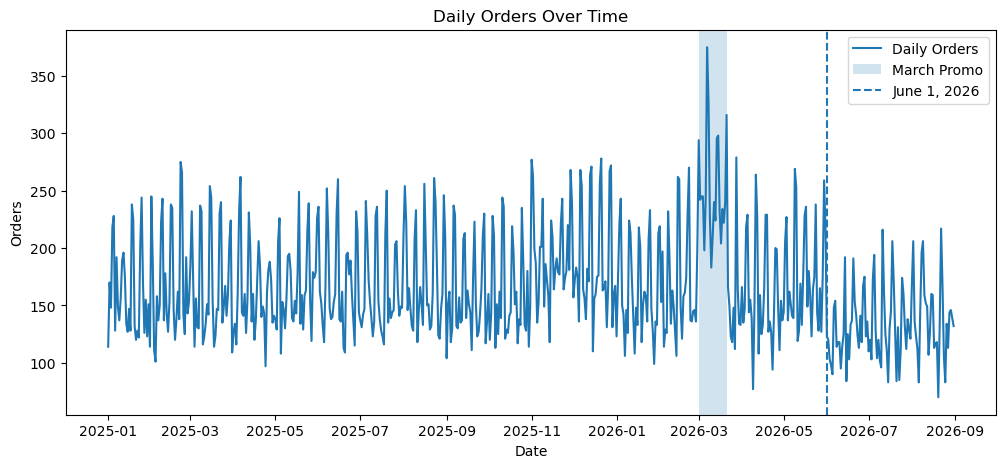

In [123]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    daily_ops["date"],
    daily_ops["orders_count"],
    label="Daily Orders"
)

# March 2026 promo window
plt.axvspan(
    pd.Timestamp("2026-03-01"),
    pd.Timestamp("2026-03-21"),
    alpha=0.2,
    label="March Promo"
)

# June 1
plt.axvline(
    pd.Timestamp("2026-06-01"),
    linestyle="--",
    label="June 1, 2026"
)

plt.title("Daily Orders Over Time")
plt.xlabel("Date")
plt.ylabel("Orders")
plt.legend()
plt.show()

Time-based train/test split

In [124]:
split_index = int(len(daily_ops) * 0.8)

train = daily_ops.iloc[:split_index].copy()
test = daily_ops.iloc[split_index:].copy()

print("Training:", train["date"].min(), "to", train["date"].max())
print("Testing:", test["date"].min(), "to", test["date"].max())

Training: 2025-01-01 00:00:00 to 2026-05-01 00:00:00
Testing: 2026-05-02 00:00:00 to 2026-08-31 00:00:00


Naive baseline

In [125]:
test["predicted_orders"] = daily_ops["orders_count"].shift(1).iloc[split_index:].values

mae = (test["orders_count"] - test["predicted_orders"]).abs().mean()

print("Naive Baseline MAE:", mae)

Naive Baseline MAE: 34.80327868852459


Checking level shift after June 1

In [126]:
before_june = daily_ops[
    (daily_ops["date"] >= "2026-05-02") &
    (daily_ops["date"] < "2026-06-01")
]

after_june = daily_ops[
    (daily_ops["date"] >= "2026-06-01") &
    (daily_ops["date"] < "2026-07-01")
]

print("Average orders before June 1:", before_june["orders_count"].mean())
print("Average orders after June 1:", after_june["orders_count"].mean())

Average orders before June 1: 175.9
Average orders after June 1: 129.23333333333332


Station F Conclusion
1. Daily orders were plotted with the March 2026 promo period and June 1, 2026 marked.
2. A time-based 80/20 split was used without shuffling the data.
3. A naive previous-day baseline gave an MAE of about 34.80 orders.
4. Average daily orders decreased from about 175.9 before June 1 to 129.2 in June, showing a clear level shift after June 1.

Station G

Checking the messages

In [129]:
support_tickets["raw_message"].head(10)
pd.set_option("display.max_colwidth", None)

support_tickets["raw_message"].head(10)

0                                      Want to return 51230 — item damaged. Confirmation to priya.shah321@yahoo.com please. My number is +1-995-822-1877.
1                                   Package for order 53361 still not here. Reach me at +1-335-991-8538 or noah.ortiz850@yahoo.com. Tracking looks stuck.
2                                      Package for order 52080 still not here. Reach me at +1-509-856-6229 or dev.kim540@yahoo.com. Tracking looks stuck.
3                                   Double charged for 52986. Last four of card on file. Mail receipt to grace.patel765@gmail.com. Phone +1-274-666-6528.
4    Double charged for 50475. Last four of card on file. Mail receipt to owen.khan121@yahoo.com. Phone +1-430-627-6266. Also CC ops+10121@pulsecart.com.
5                        Package for order 53325 still not here. Reach me at +1-728-738-8733 or maya.bennett843@pulsecart-mail.com. Tracking looks stuck.
6                               Package for order 50837 still not here. Reac

Regular expressions were used to extract order IDs, email addresses, and phone numbers from support ticket messages.

In [130]:
order_pattern = r"\b\d{5}\b"

email_pattern = r"[\w.+-]+@[\w.-]+\.[A-Za-z]{2,}"

phone_pattern = r"\+\d-\d{3}-\d{3}-\d{4}"

Extracting them

In [132]:
support_tickets["order_id_extracted"] = support_tickets["raw_message"].str.extract(
    f"({order_pattern})", expand=False
)

support_tickets["email_extracted"] = support_tickets["raw_message"].str.extract(
    f"({email_pattern})", expand=False
)

support_tickets["phone_extracted"] = support_tickets["raw_message"].str.extract(
    f"({phone_pattern})", expand=False
)
support_tickets[
    ["raw_message", "order_id_extracted", "email_extracted", "phone_extracted"]
].head(10)

,raw_message,order_id_extracted,email_extracted,phone_extracted
0,Want to return 51230 — item damaged. Confirmation to priya.shah321@yahoo.com please. My number is +1-995-822-1877.,51230,priya.shah321@yahoo.com,+1-995-822-1877
1,Package for order 53361 still not here. Reach me at +1-335-991-8538 or noah.ortiz850@yahoo.com. Tracking looks stuck.,53361,noah.ortiz850@yahoo.com,+1-335-991-8538
2,Package for order 52080 still not here. Reach me at +1-509-856-6229 or dev.kim540@yahoo.com. Tracking looks stuck.,52080,dev.kim540@yahoo.com,+1-509-856-6229
3,Double charged for 52986. Last four of card on file. Mail receipt to grace.patel765@gmail.com. Phone +1-274-666-6528.,52986,grace.patel765@gmail.com,+1-274-666-6528
4,Double charged for 50475. Last four of card on file. Mail receipt to owen.khan121@yahoo.com. Phone +1-430-627-6266. Also CC ops+10121@pulsecart.com.,50475,owen.khan121@yahoo.com,+1-430-627-6266
5,Package for order 53325 still not here. Reach me at +1-728-738-8733 or maya.bennett843@pulsecart-mail.com. Tracking looks stuck.,53325,maya.bennett843@pulsecart-mail.com,+1-728-738-8733
6,Package for order 50837 still not here. Reach me at +1-314-300-6822 or marcus.ortiz214@outlook.com. Tracking looks stuck.,50837,marcus.ortiz214@outlook.com,+1-314-300-6822
7,Package for order 51520 still not here. Reach me at +1-258-518-7072 or imani.bennett397@outlook.com. Tracking looks stuck.,51520,imani.bennett397@outlook.com,+1-258-518-7072
8,Package for order 50321 still not here. Reach me at +1-874-708-4283 or diego.patel80@yahoo.com. Tracking looks stuck.,50321,diego.patel80@yahoo.com,+1-874-708-4283
9,ETA missed on 50155. I already emailed elena.patel42@yahoo.com. Need a callback at +1-373-258-8376.,50155,elena.patel42@yahoo.com,+1-373-258-8376


Calculating hit rates

In [133]:
total = len(support_tickets)

order_hit_rate = support_tickets["order_id_extracted"].notna().mean() * 100
email_hit_rate = support_tickets["email_extracted"].notna().mean() * 100
phone_hit_rate = support_tickets["phone_extracted"].notna().mean() * 100

print("Total messages:", total)
print("Order ID hit rate:", round(order_hit_rate, 2), "%")
print("Email hit rate:", round(email_hit_rate, 2), "%")
print("Phone hit rate:", round(phone_hit_rate, 2), "%")

Total messages: 520
Order ID hit rate: 100.0 %
Email hit rate: 98.08 %
Phone hit rate: 83.08 %


Station G Conclusion:-
Regular expressions were used to extract order IDs, email addresses, and phone numbers from all 520 support ticket messages.
1. Order ID hit rate: 100.00%
2. Email hit rate: 98.08%
3. Phone hit rate: 83.08%
The extraction was performed programmatically across all support messages rather than parsing the rows manually.

Station H

Checking the image folders

In [137]:
import os
image_folder = "data/images"
print(os.listdir(image_folder))

['damaged', 'normal', 'wrong_item']


In [138]:
for folder in os.listdir(image_folder):
    folder_path = os.path.join(image_folder, folder)
    if os.path.isdir(folder_path):
        print(folder, ":", len(os.listdir(folder_path)), "images")

damaged : 80 images
normal : 80 images
wrong_item : 80 images


Load and split the images

In [140]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

image_size = (64, 64)
batch_size = 16

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20
)

train_data = datagen.flow_from_directory(
    "data/images",
    target_size=image_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=42
)

test_data = datagen.flow_from_directory(
    "data/images",
    target_size=image_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)
print(train_data.class_indices)

Found 192 images belonging to 3 classes.
Found 48 images belonging to 3 classes.
{'damaged': 0, 'normal': 1, 'wrong_item': 2}


Build the CNN

In [141]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(16, (3, 3), activation="relu", input_shape=(64, 64, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(32, activation="relu"),
    Dense(3, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

C:\Users\datta_84fscca\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       200,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 205,923 (804.39 KB)

 Trainable params: 205,923 (804.39 KB)

 Non-trainable params: 0 (0.00 B)

Train

In [143]:
history = model.fit(
    train_data,
    epochs=10,
    validation_data=test_data
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 1.0000 - loss: 3.8545e-04 - val_accuracy: 1.0000 - val_loss: 3.3850e-04
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 1.0000 - loss: 3.1962e-04 - val_accuracy: 1.0000 - val_loss: 2.9743e-04
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 1.0000 - loss: 2.9577e-04 - val_accuracy: 1.0000 - val_loss: 2.6118e-04
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 1.0000 - loss: 2.6422e-04 - val_accuracy: 1.0000 - val_loss: 2.3107e-04
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 1.0000 - loss: 2.2747e-04 - val_accuracy: 1.0000 - val_loss: 2.0550e-04
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 1.0000 - loss: 2.0558e-04 - val_accuracy: 1.0000 - val_loss: 1.8413e-04
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 1.0000 - loss: 1.8276e-04 - val_accuracy: 1.0000 - val_loss: 1.6603e-04
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - ac

Evaluating the accuracy

In [144]:
test_loss, test_accuracy = model.evaluate(test_data)
print("Test Accuracy:", test_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 1.0000 - loss: 1.4426e-04
Test Accuracy: 1.0


Confusion matrix

In [145]:
import numpy as np
from sklearn.metrics import confusion_matrix

test_data.reset()

predictions = model.predict(test_data)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_data.classes

cm = confusion_matrix(true_classes, predicted_classes)

print(cm)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step 
[[16  0  0]
 [ 0 16  0]
 [ 0  0 16]]


Displaying the Confusion Matrix

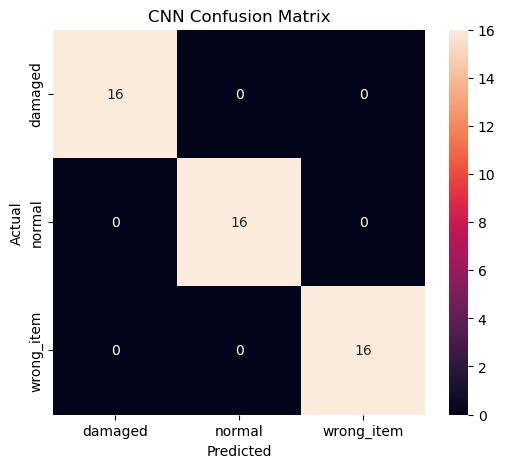

In [146]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=test_data.class_indices.keys(),
    yticklabels=test_data.class_indices.keys()
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")
plt.show()

Station H - CNN Image Classification:- 
Conclusion:-
A small CNN was trained to classify images into three classes: `damaged`, `normal`, and `wrong_item`.
The dataset contained 240 images, with 20% (48 images) held out for evaluation.
The CNN achieved 100% accuracy on the holdout set.
The confusion matrix shows:
1. Damaged: 16/16 correctly classified
2. Normal: 16/16 correctly classified
3. Wrong item: 16/16 correctly classified
There were no misclassifications in the holdout set.

Final Conclusion

This analysis covered data cleaning, exploratory analysis, statistical testing, churn prediction, customer clustering, time-series analysis, text extraction, and image classification for PulseCart.

The analysis identified differences in customer churn and product return behavior, built a time-aware churn prediction model, explored customer groups using K-Means and DBSCAN, examined changes in daily orders, extracted useful information from support messages using regular expressions, and classified product images using a small CNN.

The results provide data-driven observations that can be used to investigate customer churn, product returns, operational trends, support information, and product image quality further.

Overall, the project demonstrates an end-to-end data analysis and machine learning workflow using the PulseCart dataset.